# Analyzing Lung Sounds Datasets

In [1]:
import os
import sys
# Add the parent directory to the Python path to allow module imports
sys.path.append(os.path.dirname(os.getcwd()))

# Set random seed for reproducibility
import random
random.seed(42)

import pandas as pd
from matplotlib import pyplot as plt

from modules.dataset import ICBHIDataset, FraiwanDataset, LungSoundDataset
from modules.preprocess import *

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), "data")
if not os.path.exists(data_path):
    print(f"Data directory not found at {data_path}. Please ensure the data is downloaded and placed in the correct location.")

## Datasets Distributions

### ICBHI 2017

In [20]:
icbhi_dataset = ICBHIDataset(data_path, "all")
print(f"Dataset size: {len(icbhi_dataset)} samples")
icbhi_dataset.data.head(10)

Dataset size: 918 samples


,FilePath,Label,Age,Sex,AdultBMI (kg/m2),ChildWheight (kg),ChildHeight (cm),PatientId,RecordingIndex,ChestLocation,AcquisitionMode,RecordingEquipment
0,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Al,sc,Meditron
1,/home/leticialopes/projects/IA901/IA901_Projec...,URTI,3.00,F,NaN,19.0,99.0,I101,1b1,Pr,sc,Meditron
2,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,0.75,F,NaN,9.8,73.0,I102,1b1,Ar,sc,Meditron
3,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,70.00,F,33.00,NaN,NaN,I103,2b2,Ar,mc,LittC2SE
4,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Al,sc,Litt3200
5,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ar,sc,Litt3200
6,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Ll,sc,Litt3200
7,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Lr,sc,Litt3200
8,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pl,sc,Litt3200
9,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,70.00,F,28.47,NaN,NaN,I104,1b1,Pr,sc,Litt3200


#### Unit Test

Sample 0:
  File path: /home/leticialopes/projects/IA901/IA901_Project/data/ICBHI_final_database/101_1b1_Al_sc_Meditron.wav
  Sample rate: 44100
  Audio shape: (882000,)
  Label: URTI


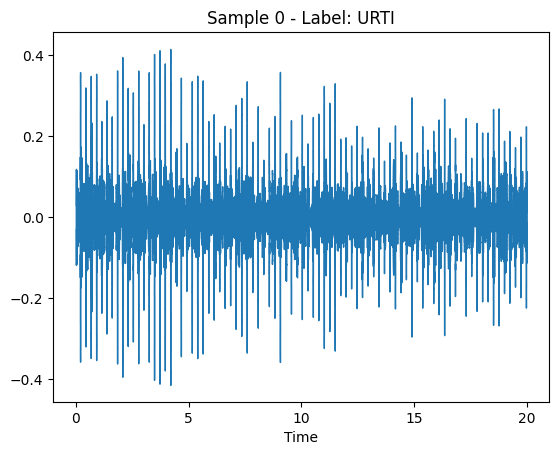

In [4]:
icbhi_dataset.unit_test(idx=0)

#### Class Distribution

In [5]:
def plot_label_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of labels in the dataset.
    Args:
        dataset (LungSoundDataset): The dataset containing label information.
    """
    data = dataset.data
    label_counts = data["Label"].value_counts()
    label_counts.plot(kind="bar")
    display(label_counts)
    plt.title("Label Distribution")
    plt.xlabel("Diagnosis")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

Label
COPD              793
Pneumonia          37
Healthy            35
URTI               23
Bronchiectasis     16
Bronchiolitis      13
Asthma              1
Name: count, dtype: int64

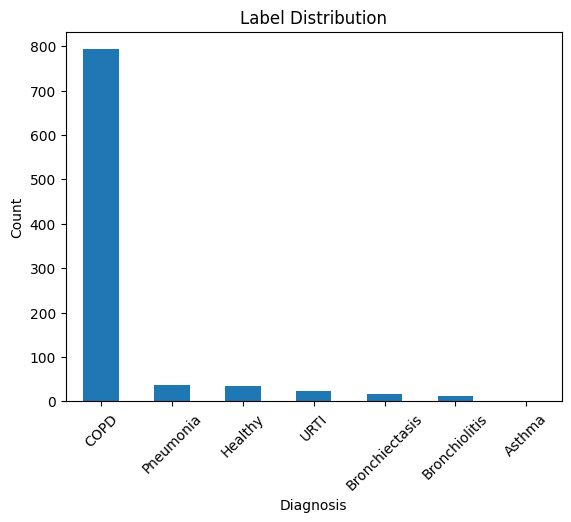

In [6]:
plot_label_distribution(icbhi_dataset)

#### Demographics

In [7]:
def plot_demographic_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of demographic features in the dataset (Age and Sex).
    Args:
        dataset (LungSoundDataset): The dataset containing demographic information.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    data = dataset.data
    
    # Age distribution
    age_count = data["Age"].value_counts().sort_index()
    display(age_count)
    data["Age"].plot(kind="hist", bins=100, ax=axes[0], color="skyblue")
    axes[0].set_title("Age Distribution")
    axes[0].set_xlabel("Age")
    axes[0].set_ylabel("Count")

    # Sex distribution
    sex_count = data["Sex"].value_counts()
    display(sex_count)
    data["Sex"].value_counts().plot(kind="bar", ax=axes[1], color="salmon")
    axes[1].set_title("Sex Distribution")
    axes[1].set_xlabel("Sex")
    axes[1].set_ylabel("Count")

Age
0.25      1
0.50      1
0.67      4
0.75      1
0.83      5
1.00      8
2.00     11
3.00     15
4.00      6
5.00      4
6.00      1
7.00      1
9.00      1
10.00     4
11.00     1
12.00     1
13.00     2
14.00     4
16.00     3
19.00     1
21.00     1
45.00    20
50.00     2
56.00    48
57.00    21
58.00    50
60.00     8
61.00    11
62.00    18
63.00    53
65.00    55
66.00    28
67.00    41
68.00    44
69.00    14
70.00    28
71.00    47
72.00    23
73.00    35
74.00    38
75.00    76
77.00    35
78.00     6
79.00    29
80.00    17
81.00    11
83.00     1
84.00     6
85.00    66
93.00     5
Name: count, dtype: int64

Sex
M    589
F    323
Name: count, dtype: int64

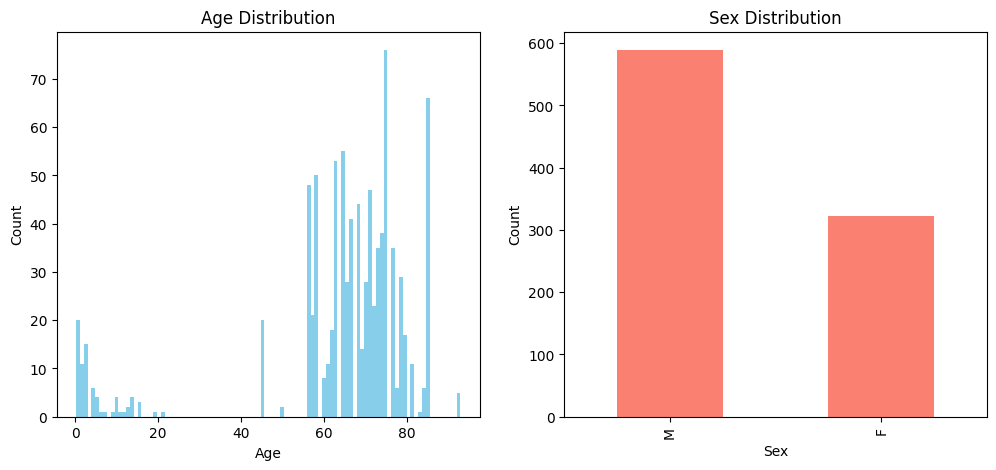

In [8]:
plot_demographic_distribution(icbhi_dataset)

#### Duration

In [9]:
# Iterate over the dataset to get the distriqution of the duration of the recordings
def plot_recording_duration_distribution(dataset: LungSoundDataset):
    """
    Plot the distribution of recording durations in the dataset.
    Args:
        data (pd.DataFrame): The dataset containing recording duration information.
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    durations = []
    durations_by_label = {label: [] for label in dataset.classes}
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        duration = sample.duration
        durations.append(duration)
        durations_by_label[label].append(duration)
    pd.Series(durations).plot(kind="hist", bins=50, ax=ax)
    ax.set_title("Recording Duration Distribution")
    ax.set_xlabel("Duration (seconds)")
    ax.set_ylabel("Count")
    plt.show()

    # For each label, plot the distribution
    fig, ax = plt.subplots(4, 2, figsize=(10, 10), sharey=False)
    ax = ax.flatten()
    for label, durations in durations_by_label.items():
        print(f"Label: {label}, Mean Duration: {pd.Series(durations).mean():.2f} seconds")
        pd.Series(durations).plot(kind="hist", bins=50, ax=ax[dataset.classes.index(label)])
        ax[dataset.classes.index(label)].set_title(f"{label}")
        ax[dataset.classes.index(label)].set_xlabel("Duration (seconds)")
        ax[dataset.classes.index(label)].set_ylabel("Count")
    plt.tight_layout()
    plt.show()

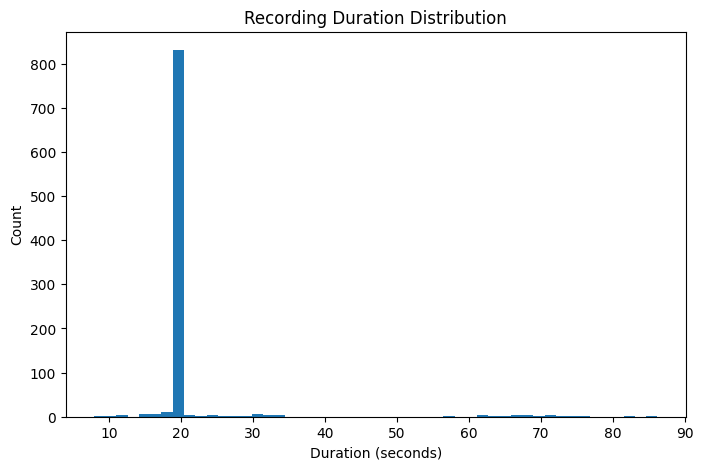

Label: Asthma, Mean Duration: 20.00 seconds
Label: Bronchiectasis, Mean Duration: 20.00 seconds
Label: Bronchiolitis, Mean Duration: 20.00 seconds
Label: COPD, Mean Duration: 21.73 seconds
Label: Healthy, Mean Duration: 19.99 seconds
Label: Pneumonia, Mean Duration: 20.00 seconds
Label: URTI, Mean Duration: 19.98 seconds


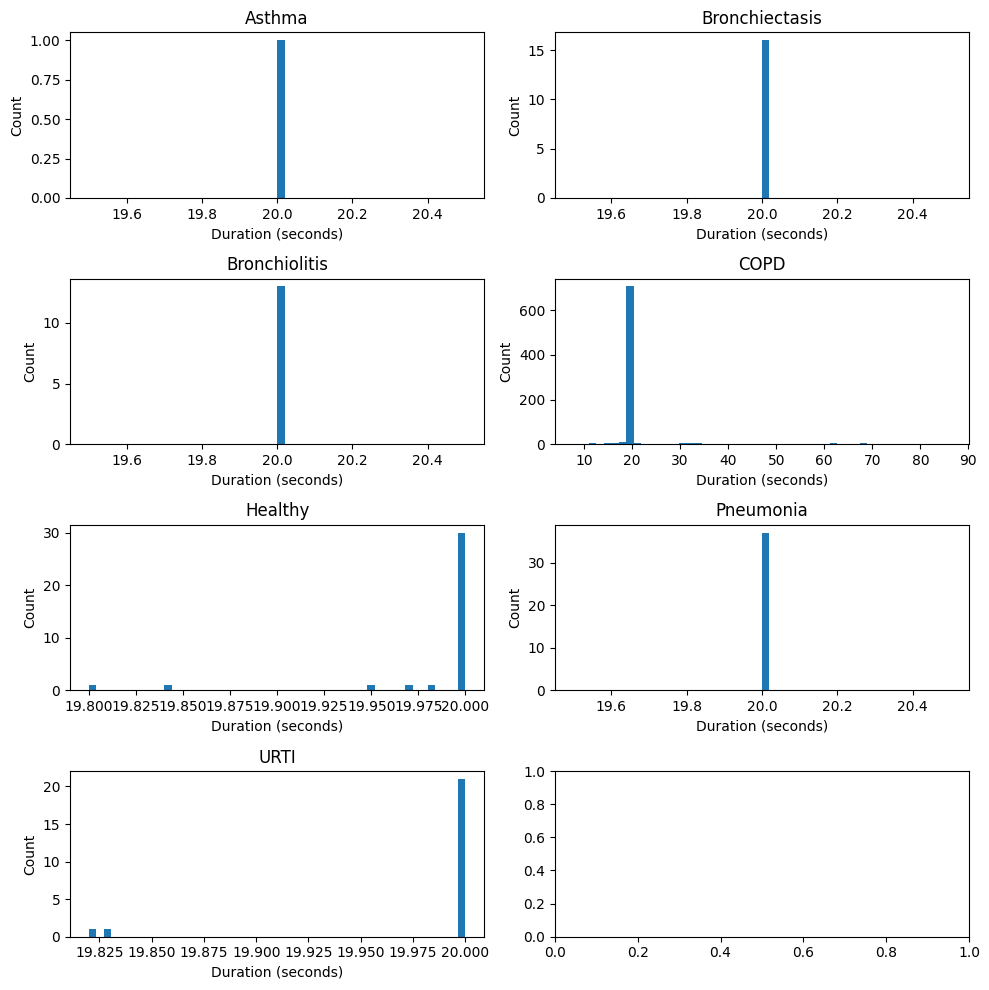

In [10]:
plot_recording_duration_distribution(icbhi_dataset)

### Fraiwan et. al. 2021

In [11]:
fraiwan_dataset = FraiwanDataset(data_path, "all")
print(f"Dataset size: {len(fraiwan_dataset)} samples")
fraiwan_dataset.data.head(10)

Dataset size: 255 samples


,FilePath,Label,FilterCode,PatientId,Sound type,Location,Age,Sex
0,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P100,N,P R M,70.0,F
1,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P101,E W,P L M,12.0,F
2,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P102,N,P L L,41.0,M
3,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P103,N,P R U,81.0,F
4,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P104,E W,P L U,45.0,F
5,/home/leticialopes/projects/IA901/IA901_Projec...,Lung Fibrosis,B,P105,Crep,A U R,44.0,M
6,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P106,E W,P L U,45.0,F
7,/home/leticialopes/projects/IA901/IA901_Projec...,Asthma,B,P107,E W,P L U,59.0,F
8,/home/leticialopes/projects/IA901/IA901_Projec...,COPD,B,P108,E W,P R L,63.0,M
9,/home/leticialopes/projects/IA901/IA901_Projec...,Healthy,B,P109,N,P L M,26.0,M


#### Unit Test

Sample 0:
  File path: /home/leticialopes/projects/IA901/IA901_Project/data/fraiwan/Audio Files/BP100_N,N,P R M,70,F.wav
  Sample rate: 4000
  Audio shape: (54208,)
  Label: Healthy


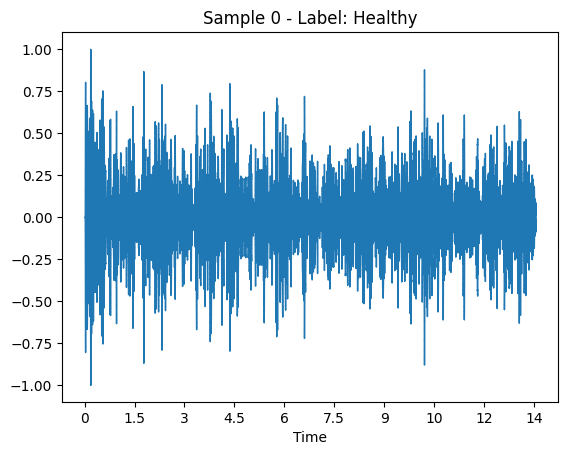

In [12]:
fraiwan_dataset.unit_test(idx=0)

#### Class Distribution

Label
Healthy          105
Asthma            96
COPD              27
Pneumonia         15
Lung Fibrosis     12
Name: count, dtype: int64

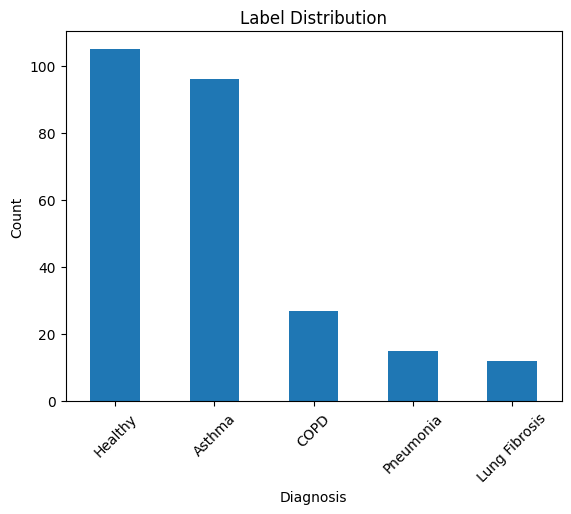

In [13]:
plot_label_distribution(fraiwan_dataset)

#### Demographics

Age
12.0     3
15.0     3
18.0     9
20.0     3
21.0     6
24.0     9
26.0     3
27.0     6
29.0     3
30.0     9
31.0     6
32.0     3
33.0     6
36.0     6
38.0    12
40.0     9
41.0     6
42.0     3
43.0     9
44.0     3
45.0     6
46.0     3
49.0     3
50.0    12
51.0     6
52.0     6
53.0    12
56.0     3
57.0     6
58.0     3
59.0     9
60.0     9
62.0     3
63.0     3
64.0     3
65.0     3
66.0     3
68.0     3
70.0    12
72.0     9
73.0     3
74.0     3
75.0     3
76.0     6
81.0     3
90.0     3
Name: count, dtype: int64

Sex
M    156
F     99
Name: count, dtype: int64

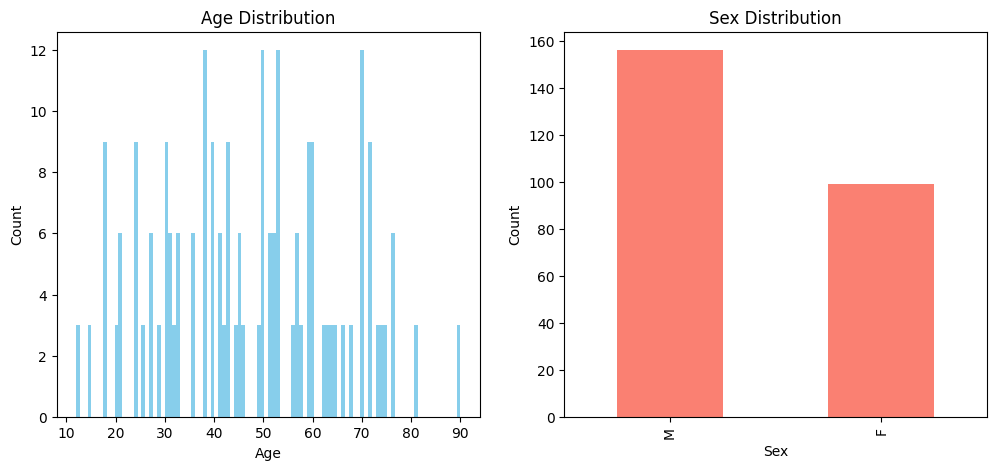

In [14]:
plot_demographic_distribution(fraiwan_dataset)

#### Duration

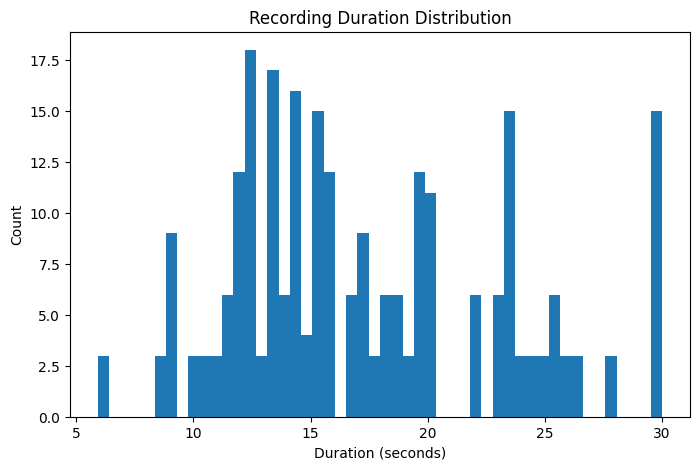

Label: Asthma, Mean Duration: 16.99 seconds
Label: COPD, Mean Duration: 17.59 seconds
Label: Healthy, Mean Duration: 17.82 seconds
Label: Lung Fibrosis, Mean Duration: 15.41 seconds
Label: Pneumonia, Mean Duration: 19.58 seconds


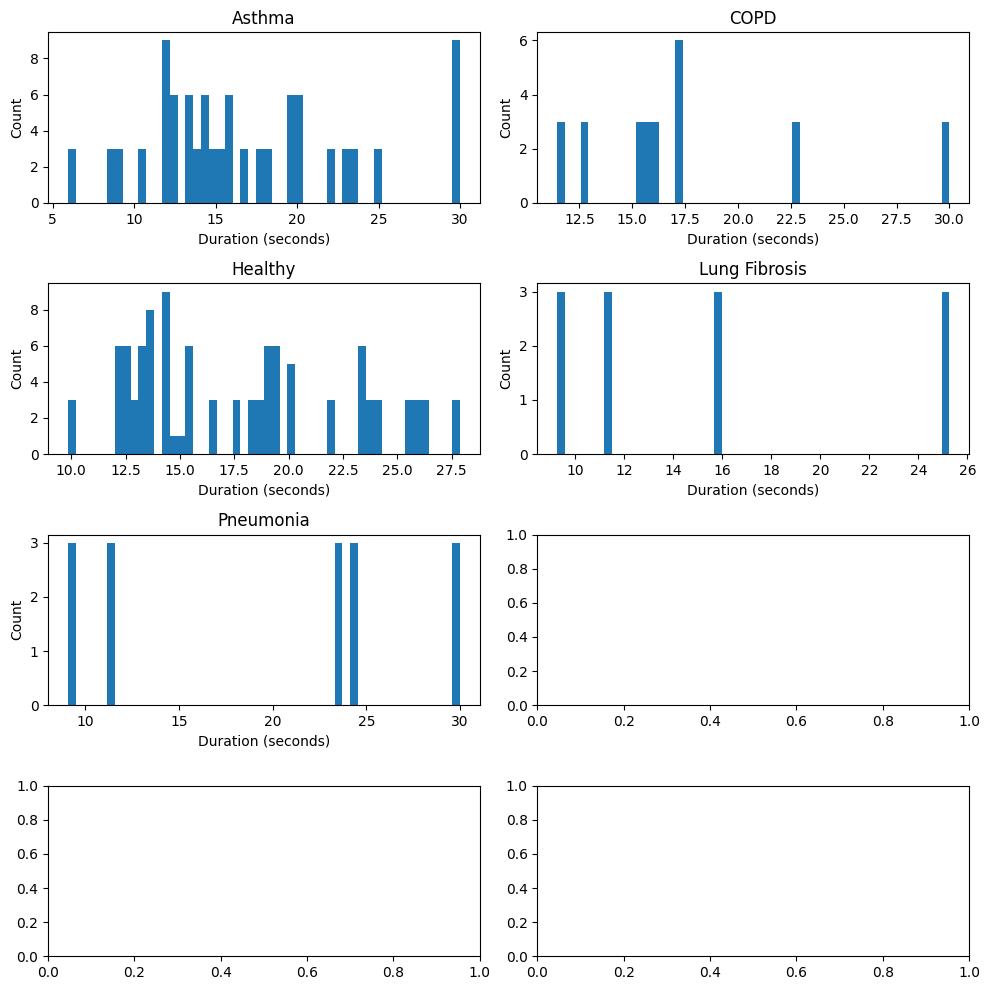

In [15]:
plot_recording_duration_distribution(fraiwan_dataset)

### Combined Datasets

In [16]:
datasets = {
    "ICBHI": icbhi_dataset,
    "Fraiwan": fraiwan_dataset,
}

combined_data = pd.concat([dataset.data for dataset in datasets.values()], ignore_index=True)
print(f"Combined dataset size: {len(combined_data)} samples")

Combined dataset size: 1173 samples


#### Class Distribution

Label
COPD              820
Healthy           140
Asthma             97
Pneumonia          52
URTI               23
Bronchiectasis     16
Bronchiolitis      13
Lung Fibrosis      12
Name: count, dtype: int64

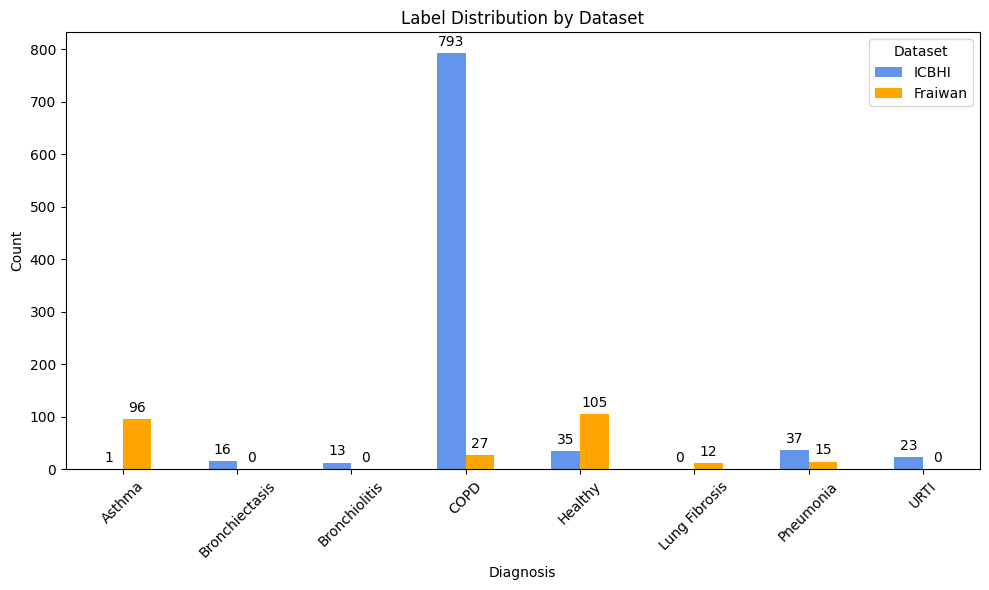

In [17]:
display(combined_data["Label"].value_counts())

all_labels = sorted(combined_data["Label"].dropna().unique())
counts_df = pd.DataFrame(
    {
        name: dataset.data["Label"].value_counts().reindex(all_labels, fill_value=0)
        for name, dataset in datasets.items()
    }
)

ax = counts_df.plot(kind="bar", figsize=(10, 6), color=["cornflowerblue", "orange"])
ax.set_title("Label Distribution by Dataset")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Dataset")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.tight_layout()
plt.show()